In [1]:
# poetry add langgraph
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

In [3]:
# 에이전트가 사용할 도구 정의
@tool
def recommend_recipe(dish: str):
    """ 주어진 요리에 대한 간단한 레시피를 제공합니다. """
    recipes = {
        "파스타": "재료: 스파게티 면, 토마토 소스, 올리브 오일, 마늘. 면을 삶고 소스를 부어주세요.",
        "불고기": "재료: 소고기, 간장, 설탕, 마늘. 고기를 양념에 재워 볶아주세요.",
        "샐러드": "재료: 양상추, 토마토, 오이, 드레싱. 채소를 썰어 드레싱과 버무려주세요."
    }
    # get(key) : key값이 없으면 보통 에러가 나지만 get은 에러가 나지 않게 None을 내보냄
    # dish = key -> 키에 해당하는 값이 없으면 '죄송하지만...' 출력
    return recipes.get(dish, '죄송하지만 해당 요리의 레시피를 찾을 수 없습니다.' ) 

# 도구 리스트에 추가
tools = [recommend_recipe]

# ToolNode 생성
tool_node = ToolNode(tools)

In [4]:
# 워크플로 그래프 생성 및 상태 관리

# 모델 GPT -> 도구 연결
model = ChatOpenAI(model='gpt-4o-mini', temperature=0).bind_tools(tools)

# 계속할지 여부를 결정하는 함수 정의
def should_continue(state: MessagesState):
    messages = state['messages']
    last_message = messages[-1] # 맨 끝을 뜻하는 -1
    # LLM이 도구 호출을 하면 'tools' 노드로
    if last_message.tool_calls:
        return 'tools'
    # 그렇지 않으면 중지(사용자에게 응답)
    return END

# 모델을 호출하는 함수 정의
def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    # 기존 목록에 추가되기 때문에 목록을 반환한다
    return {'messages' : [response]}


In [5]:
# 새로운 그래프 정의
workflow = StateGraph(MessagesState)

# 노드 정의
workflow.add_node('agent', call_model) # agent가 call_model을 호출하도록
workflow.add_node('tools', tool_node) # tools(도구)는 tool_node

# 진입점을 'agent'로 설정 -> 첫번째로 호출되는 노드를 이미
workflow.set_entry_point('agent')

# 조건부 경로 추가
workflow.add_conditional_edges(
    'agent',  # 먼저, 시작 노드를 정의 -> 'agent' 노드가 호출된 후의 경로를 지정
    should_continue,  # 어느 노드가 다음에 호출될지 결정하는 함수 전달
)

# 'tools'에서 'agent'로의 일반 경로 추가 -> 'tools'가 호출된 후 'agent' 노드가 다음에 호출된다는 것을 의미
workflow.add_edge('tools', 'agent')

In [6]:
checkpointer = MemorySaver()

app = workflow.compile(checkpointer=checkpointer)

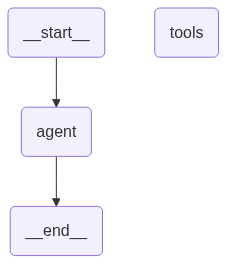

In [ ]:
from IPython.display import Image, display
# 예외처리
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# 랭그래프 기본 시작, 끝, 노드를 agent로
# start 다음 agent(첫번째로 호출되는 노드로 설정했기 때문)